CS23B1013 Raja simha

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
DATASET_PATH = "DATASET/Dataset_BUSI_with_GT"   # change if needed
BATCH_SIZE = 32
EPOCHS = 10
IMG_SIZE = 224

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)




Using device: cpu


In [21]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])



In [22]:
dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))


Classes: ['benign', 'malignant', 'normal']
Total images: 1578


In [23]:
dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))
print("Class mapping:", dataset.class_to_idx)


Classes: ['benign', 'malignant', 'normal']
Total images: 1578
Class mapping: {'benign': 0, 'malignant': 1, 'normal': 2}


In [27]:
labels_list = [label for _, label in dataset]
print("Unique labels:", set(labels_list))


Unique labels: {0, 1, 2}


In [ ]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print("Train samples:", train_size)
print("Validation samples:", val_size)


CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=3, bias=True)
  )
)


In [28]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print("Train samples:", train_size)
print("Validation samples:", val_size)


Train samples: 1262
Validation samples: 316


In [29]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)


In [30]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 3)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CNN().to(device)

print(model)


CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=3, bias=True)
  )
)


In [31]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)


In [32]:
for epoch in range(EPOCHS):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} Loss: {avg_loss}")


Epoch 1/10 Loss: 0.9618484303355217
Epoch 2/10 Loss: 0.7507339805364609
Epoch 3/10 Loss: 0.5973291717469692
Epoch 4/10 Loss: 0.4903043806552887
Epoch 5/10 Loss: 0.42246287874877453
Epoch 6/10 Loss: 0.2761638294905424
Epoch 7/10 Loss: 0.1935259947553277
Epoch 8/10 Loss: 0.11806987822055817
Epoch 9/10 Loss: 0.10451851799152792
Epoch 10/10 Loss: 0.08014112983364612


In [33]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())


In [34]:
print("Classification Report\n")

print(classification_report(y_true, y_pred, target_names=dataset.classes))


Classification Report

              precision    recall  f1-score   support

      benign       0.76      0.87      0.81       180
   malignant       0.70      0.60      0.65        81
      normal       0.88      0.65      0.75        55

    accuracy                           0.76       316
   macro avg       0.78      0.71      0.74       316
weighted avg       0.77      0.76      0.76       316



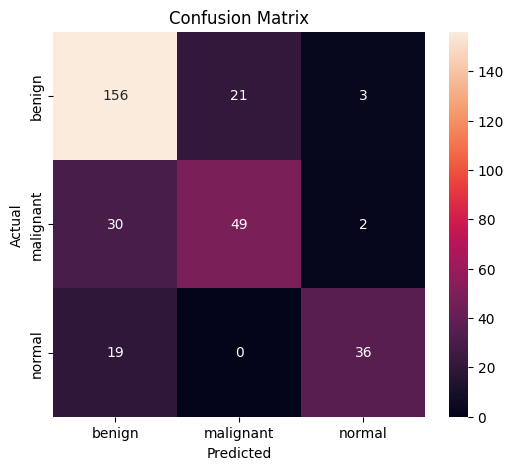

In [35]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


In [37]:
torch.save(model.state_dict(), "busi_model.pth")




In [40]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

all_labels = []
all_probs = []

model.eval()

with torch.no_grad():

    for inputs, labels in val_loader:

        inputs = inputs.to(device)

        outputs = model(inputs)

        probs = torch.softmax(outputs, dim=1)

        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

n_classes = 3

y_test = label_binarize(all_labels, classes=[0,1,2])

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


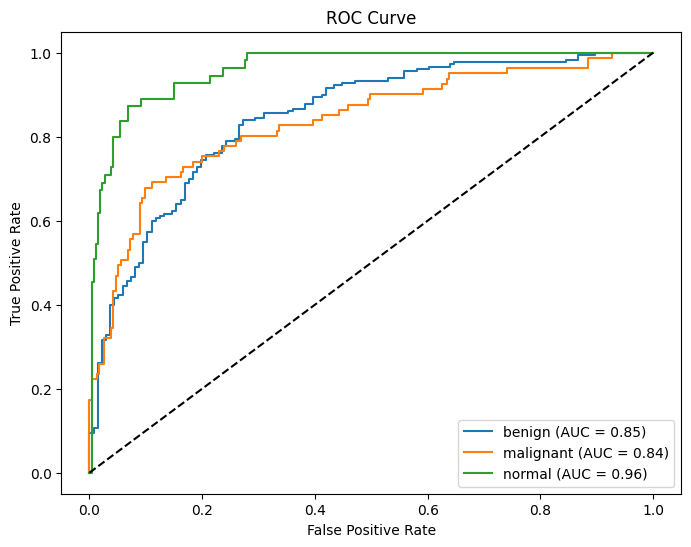

In [41]:
import matplotlib.pyplot as plt

class_names = dataset.classes

plt.figure(figsize=(8,6))

for i in range(n_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()


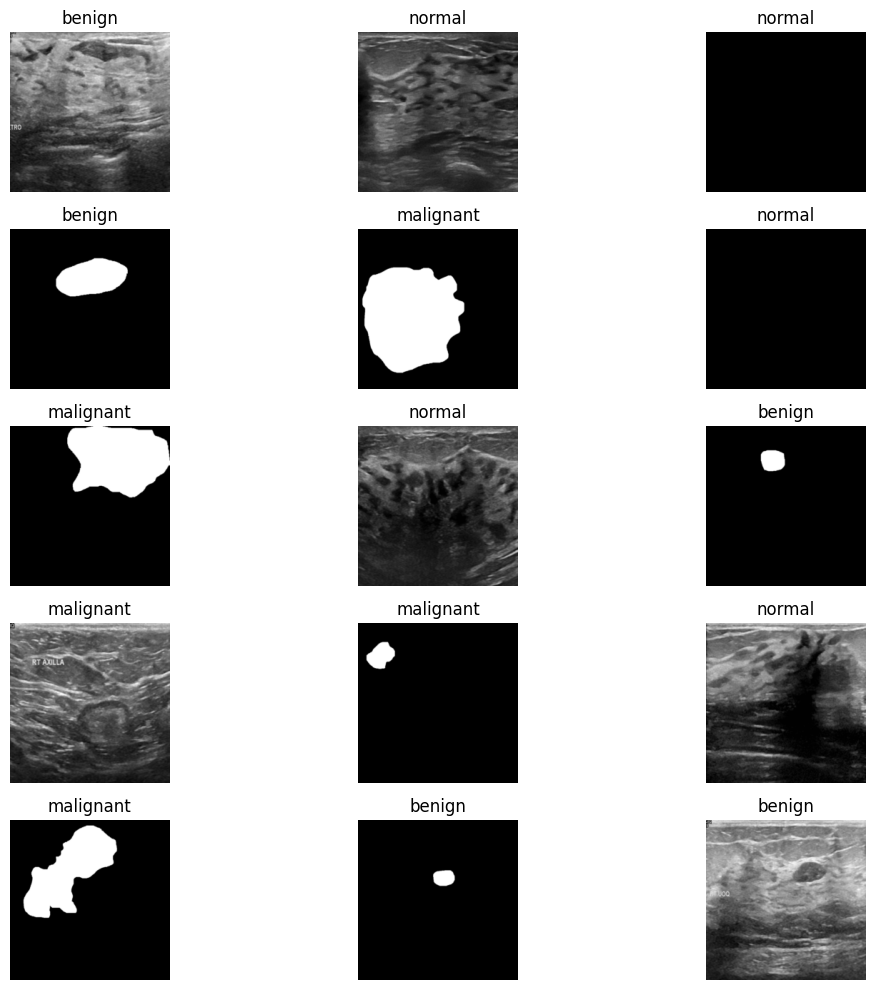

In [42]:
import matplotlib.pyplot as plt
import numpy as np

class_names = dataset.classes

images, labels = next(iter(train_loader))

plt.figure(figsize=(12,10))

for i in range(15):

    ax = plt.subplot(5,3,i+1)
    ax.axis("off")

    img = images[i].permute(1,2,0).numpy()

    label = class_names[labels[i]]

    ax.set_title(label)

    plt.imshow(img)

plt.tight_layout()
plt.show()
